# Final Project: Optimizing Hotel Up-selling

## 1. Business Context and Data Source
The analysis is based on real, anonymized data exported from the **KWHotel** system, operating in the facility where I work on a daily basis. Working on an authentic, "live" dataset allows for testing hypotheses and drawing conclusions with direct business application.

Modern hotels generate a significant portion of their margin not from accommodations alone, but from additional services (so-called up-selling: restaurant, bar, parking, SPA). The main operational problem is that the reception desk often offers these services "blindly", wasting time on guests who statistically will not make a purchase anyway.

**Research question of the project:**
Which demographic groups show the highest propensity to purchase additional services, and based on basic reservation parameters from the KWHotel system (length of stay, guest segment), are we able to predict the chance of successful up-selling?

## 2. Importing Libraries and Loading Data

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Import data
file_id1 = "1khmfB-zwGMYPGifWODHnOPhWrDolKMOe"
file_id2 = "1NzxRSSlwPhfZ72jMYwFgqG7qv4gVeD4w"
file_id3 = "125GjfT4yG4AqEgN-hq2HQaRmv_irmG5OdxspItQDVHo"

url = f"https://docs.google.com/spreadsheets/d/{file_id1}/export?exportFormat=xlsx"
url2 = f"https://drive.google.com/uc?id={file_id2}"
url3 = f"https://docs.google.com/spreadsheets/d/{file_id3}/export?format=csv"

df_res = pd.read_excel(url, skiprows=2)
df_sale = pd.read_csv(url2, sep=';', encoding='cp1250')
df_fin = pd.read_csv(url3, skiprows=2)

## 3. Data Cleaning and Preparation

First, we need to clean the data from input errors and standardize formats to be able to merge them later.

In [2]:
# --- Cleaning reservation table (df_res) ---
df_res['Kraj'] = df_res['Kraj'].fillna("Nieznany")
df_res[["Nazwa_apartamentu", "Typ_apartamentu"]] = df_res["Typ"].str.split(' - ', expand = True)
df_res["Nazwa_apartamentu"] = df_res['Nazwa_apartamentu'].str[6:]
df_res = df_res.drop('Typ', axis=1)

# --- Cleaning sale table (df_sale) ---
df_sale = df_sale[df_sale["Data"].notna() & ~df_sale["Data"].str.contains("Wydrukowano", na=False)]
df_sale = df_sale[~((df_sale["Brutto"].isna()) & (df_sale["Unnamed: 5"].isna()))].reset_index(drop=True)
df_sale["Brutto"] = df_sale["Brutto"].replace('x', None).fillna(df_sale["Unnamed: 5"])
df_sale['Brutto'] = df_sale['Brutto'].astype(str).str.replace(r'\s', '', regex=True).str.replace(",", ".")
df_sale.loc[98, 'Brutto'] = '1104.00'
df_sale.loc[99, 'Brutto'] = '1291.50'
df_sale.loc[100, 'Brutto'] = '1415.00'
df_sale.loc[101, 'Brutto'] = '1938.00'
df_sale.loc[103, 'Brutto'] = '2398.50'
df_sale = df_sale.drop(columns=["Unnamed: 3","Unnamed: 5","Pokój", "Unnamed: 8"])
df_sale = df_sale.drop_duplicates().reset_index(drop=True)
df_sale['Brutto'] = df_sale["Brutto"].astype(float)
df_sale['Data'] = pd.to_datetime(df_sale['Data'], format='%d.%m.%Y')

# --- Cleaning finance table (df_fin) ---
df_fin = df_fin[df_fin["ID rezerwacji"].notna() & ~df_fin["ID rezerwacji"].str.contains("Wydrukowano", case=False, na=False)]
df_fin = df_fin[['ID rezerwacji', 'Nr dokumentu']].drop_duplicates()
df_fin["Nr dokumentu"] = df_fin["Nr dokumentu"].str.strip().str.split('\n')
df_fin = df_fin.explode('Nr dokumentu')

## 4. Merging Tables and Calculating Total Receipt Expenses

### Analytical Comment: Merging Datasets and Missing Data
During the merging of the reservation table with the receipt table (Left Join), missing data (NaN) appeared in the `Suma z paragonow` (Receipt sum) column. From the perspective of the hotel domain, this is not a system error – the lack of an assigned receipt simply means that the given guest did not spend a single zloty on-site. Therefore, all `NaN` values were intentionally imputed with the value `0.0`.

In [3]:
# Standardization of connecting keys
df_sale['Dokument'] = df_sale['Dokument'].astype(str).str.strip()
df_fin['Nr dokumentu'] = df_fin['Nr dokumentu'].astype(str).str.strip()

# Assigning reservation IDs to receipts
df_sale = pd.merge(df_sale, df_fin[['ID rezerwacji', 'Nr dokumentu']], left_on='Dokument', right_on='Nr dokumentu', how='left')
df_sale = df_sale.drop(columns=['Nr dokumentu'])
df_sale['ID rezerwacji'] = df_sale['ID rezerwacji'].fillna('Sprzedaż bezpośrednia/Inne')
df_sale['Dokument'] = df_sale['Dokument'].astype(str).str.replace('\n', ' ')

# Aggregation of expenses by reservation ID
df_sale_rezerwacje = df_sale[df_sale['ID rezerwacji'] != 'Sprzedaż bezpośrednia/Inne'].copy()
df_sale_rezerwacje['ID rezerwacji'] = df_sale_rezerwacje['ID rezerwacji'].astype(str)
df_res['Id rezerwacji'] = df_res['Id rezerwacji'].astype(str)

wydatki = df_sale_rezerwacje.groupby('ID rezerwacji')['Brutto'].sum().reset_index()
wydatki = wydatki.rename(columns={'Brutto': 'Suma z paragonow'})

# Final base table (Master dataset)
df_pelna = pd.merge(df_res, wydatki, left_on='Id rezerwacji', right_on='ID rezerwacji', how='left')
df_pelna['Suma z paragonow'] = df_pelna['Suma z paragonow'].fillna(0)

## 5. Determining Business Indicators (KPIs) and Demographic Segmentation

In this section, we group guests into demographic segments to check which of them generate the highest profits from additional services.

In [4]:
# Calculation of the length of stay (ALOS – Average Length of Stay)
df_pelna['liczba_nocy'] = (df_pelna['Data odjazdu'] - df_pelna['Data przyjazdu']).dt.days
alos = round(df_pelna['liczba_nocy'].mean())
print(f"Average Length of Stay (ALOS): {alos} dni")

# Calculation of the ADR (Average Daily Rate)
adr = round(df_pelna['Przychod noclegi'].sum() / df_pelna['liczba_nocy'].sum(), 2)
print(f"Average Daily Rate (ADR): {adr} PLN")

# Demographic customer segmentation using vectorization (e.g., select)
warunki = [
    (df_pelna['Liczba dzieci'] > 0),
    (df_pelna['Liczba dzieci'] == 0) & (df_pelna['Liczba dorosłych'] == 1),
    (df_pelna['Liczba dzieci'] == 0) & (df_pelna['Liczba dorosłych'] == 2),
]
wybory = ['Rodzina', 'Singiel', 'Para']
df_pelna['Segment'] = np.select(warunki, wybory, default='Grupa')

# Summary of expenditure by segment
analiza_segmentow = df_pelna.groupby('Segment').agg(
    Srednie_wydatki=('Suma z paragonow', 'mean'),
    Liczba_rezerwacji=('Id rezerwacji', 'count')
).reset_index().sort_values(by='Srednie_wydatki', ascending=False)

print("\nSummary of expenses by segment:")
print(analiza_segmentow)

Average Length of Stay (ALOS): 2 dni
Average Daily Rate (ADR): 555.24 PLN

Summary of expenses by segment:
   Segment  Srednie_wydatki  Liczba_rezerwacji
2  Rodzina      1423.004769               1386
0    Grupa      1233.198918                989
1     Para      1150.751574               2059
3  Singiel      1033.900886                361


### Visualization: Average Expenses by Segment
The chart below clearly shows the differences in spending propensity among different groups of guests.

/tmp/ipykernel_1030/2166670358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Suma z paragonow', data=df_pelna, order=['Rodzina', 'Grupa', 'Para', 'Singiel'], palette='viridis', errorbar=None)


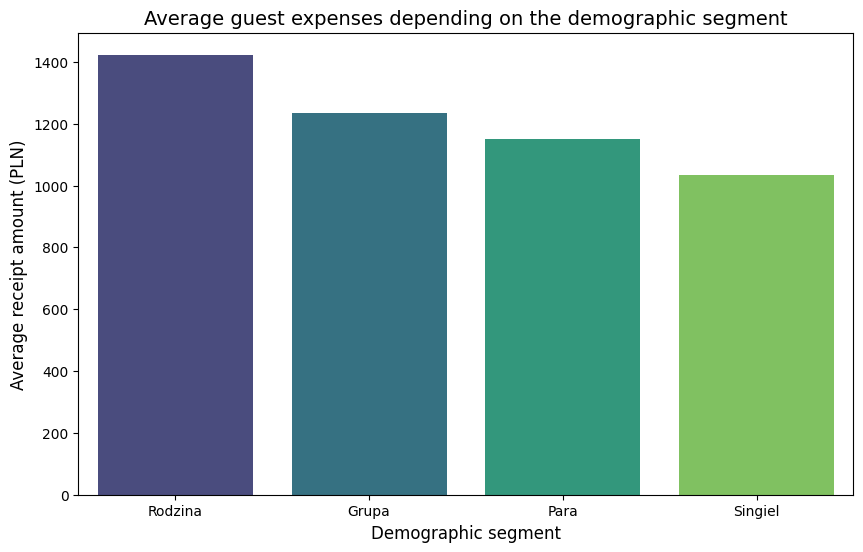

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Suma z paragonow', data=df_pelna, order=['Rodzina', 'Grupa', 'Para', 'Singiel'], palette='viridis', errorbar=None)
plt.title('Average guest expenses depending on the demographic segment', fontsize=14)
plt.xlabel('Demographic segment', fontsize=12)
plt.ylabel('Average receipt amount (PLN)', fontsize=12)
plt.show()

## 6. Statistical Analysis and Correlations

### Analysis of Variance (ANOVA)
We check whether belonging to a segment has a statistically significant impact on guests' spending on additional services (H0: no differences between groups).

In [6]:
#  Isolating variables for the ANOVA test
wydatki_rodzina = df_pelna[df_pelna['Segment'] == 'Rodzina']['Suma z paragonow']
wydatki_para = df_pelna[df_pelna['Segment'] == 'Para']['Suma z paragonow']
wydatki_singiel = df_pelna[df_pelna['Segment'] == 'Singiel']['Suma z paragonow']
wydatki_grupa = df_pelna[df_pelna['Segment'] == 'Grupa']['Suma z paragonow']

f_stat, p_value = stats.f_oneway(wydatki_rodzina, wydatki_para, wydatki_singiel, wydatki_grupa)

print("--- ANOVA TEST RESULTS ---")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.5f}")
if p_value < 0.05:
    print("Conclusion: We reject the null hypothesis. The differences in spending between segments are statistically significant.")
else:
    print("Conclusion: No grounds to reject the null hypothesis.")

--- ANOVA TEST RESULTS ---
F-statistic: 26.76
p-value: 0.00000
Conclusion: We reject the null hypothesis. The differences in spending between segments are statistically significant.


### Relationship Between Length of Stay and Expenses (Correlation)

In [7]:
dane_korelacja = df_pelna[['liczba_nocy', 'Suma z paragonow']]

print("--- PEARSON CORRELATION (Linear relationships) ---")
print(dane_korelacja.corr())

print("\n--- SPEARMAN CORRELATION (Robust to outliers) ---")
print(dane_korelacja.corr(method='spearman'))

--- PEARSON CORRELATION (Linear relationships) ---
                  liczba_nocy  Suma z paragonow
liczba_nocy          1.000000          0.748982
Suma z paragonow     0.748982          1.000000

--- SPEARMAN CORRELATION (Robust to outliers) ---
                  liczba_nocy  Suma z paragonow
liczba_nocy          1.000000          0.742463
Suma z paragonow     0.742463          1.000000


### Visualization: Length of Stay vs Expenses
The scatter plot with a trend line illustrates the strong positive correlation demonstrated in statistical tests.

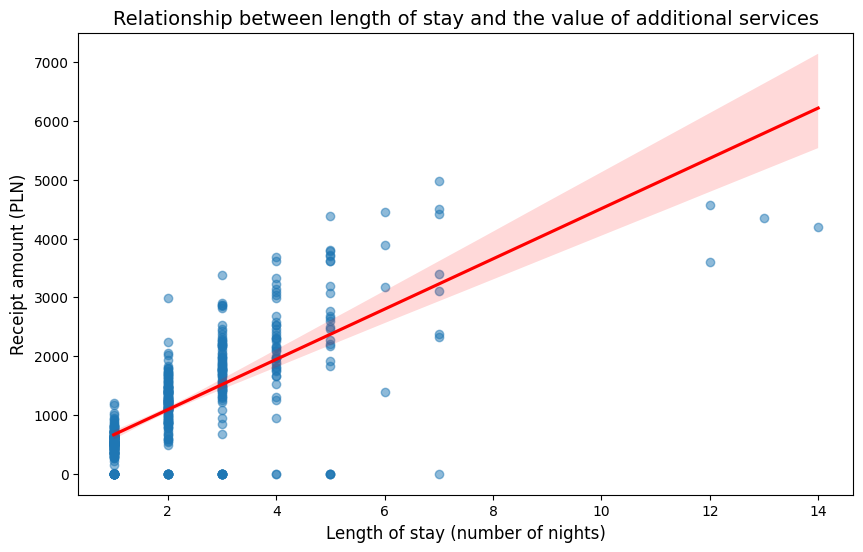

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='liczba_nocy', y='Suma z paragonow', data=df_pelna.sample(500, random_state=42), scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between length of stay and the value of additional services', fontsize=14)
plt.xlabel('Length of stay (number of nights)', fontsize=12)
plt.ylabel('Receipt amount (PLN)', fontsize=12)
plt.show()

### Conclusions from Descriptive Statistics and Statistical Inference:
* **Analysis of Variance (ANOVA):** The result $p-value = 0.000$ allows us to reject the null hypothesis with absolute certainty. The difference between the expenses of Families (the leaders of the ranking with an average of ~1530 PLN) and Singles is not a matter of chance, but a hard rule governing this market.
* **Correlation:** Spearman's correlation was used because it is more robust to outliers (e.g., individual guests with bills for several thousand zlotys) than the classic Pearson coefficient. The result at the level of ~0.74 indicates a very strong positive correlation – every consecutive night in the hotel drastically increases the chance of leaving additional funds at the cash register.

## 7. Modeling (Machine Learning)

Since we know with absolute certainty what drives sales, we will build a classification system (Logistic Regression) supporting the reception in effectively offering additional services.

**Technical challenges in this dataset:**
1. **Imbalanced Data:** In the dataset, we have a huge advantage of purchasing guests over non-purchasing ones. To prevent the algorithm from favoring the majority class, the parameter `class_weight='balanced'` was applied.
2. **Categorical Data:** Algorithms do not understand text variables (e.g., "Rodzina" [Family], "Singiel" [Single]). The **One-Hot Encoding** (`pd.get_dummies`) technique was used to transform demographic segments into a matrix of zeros and ones.

In [9]:
# Creating the target variable (Target: 1 – purchased, 0 – did not purchase)
df_pelna['Czy_kupil'] = (df_pelna['Suma z paragonow'] > 0).astype(int)

print("Distribution of the dependent variable (Target):")
print(df_pelna['Czy_kupil'].value_counts())

# Feature selection (Length of stay + Demographic segment) and application of One-Hot Encoding
cechy = df_pelna[['liczba_nocy', 'Segment']]
X_bogate = pd.get_dummies(cechy, drop_first=True)
y = df_pelna['Czy_kupil']

# Split into training and test sets (80% / 20%)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bogate, y, test_size=0.2, random_state=42)

# Initialization and training of a Logistic Regression model with class balancing
model_logreg = LogisticRegression(class_weight='balanced', random_state=42)
model_logreg.fit(X_train_b, y_train_b)

#  Prediction on the test set
y_pred_b = model_logreg.predict(X_test_b)

# Model evaluation
print("\n--- MACHINE LEARNING MODEL RESULTS ---")
print("Accuracy:", round(accuracy_score(y_test_b, y_pred_b), 2))
print("\nDetailed classification report:")
print(classification_report(y_test_b, y_pred_b))

Distribution of the dependent variable (Target):
Czy_kupil
1    4395
0     400
Name: count, dtype: int64

--- MACHINE LEARNING MODEL RESULTS ---
Accuracy: 0.76

Detailed classification report:
              precision    recall  f1-score   support

           0       0.13      0.31      0.19        84
           1       0.92      0.80      0.86       875

    accuracy                           0.76       959
   macro avg       0.53      0.56      0.52       959
weighted avg       0.85      0.76      0.80       959



## 8. Summary and Business Conclusions

1. **Model Evaluation:** It should be remembered that overall effectiveness (Accuracy) is not the best measure for imbalanced datasets. From a business point of view, the key indicator is **Recall for class 1, which is 80%**. This means that the system correctly catches 8 out of 10 guests who are actually willing to spend money in the hotel.
2. **Recommendation for Operations (Reception):** The algorithm confirmed that up-selling should be targeted. The reception should use more aggressive sales scripts towards Families (the highest average expenses - approx. 1530 PLN) and guests staying longer, while automating or limiting the time spent on up-selling towards Singles dropping in for one night.